In [1]:
import seaborn as sns
from sklearn.datasets import make_blobs

In [2]:
X,Y = make_blobs(
    n_samples=2000,
    n_features=2,
    centers=4,
    random_state=42
)

<Axes: >

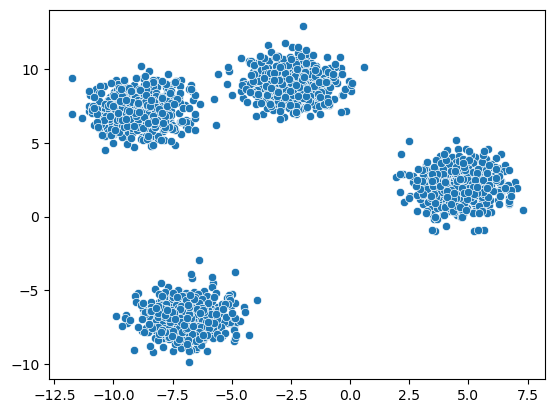

In [4]:
sns.scatterplot(
    x = X[:,0],
    y = X[:,1]
)

# Scaling is mandatory

In [8]:
from sklearn.cluster import KMeans

K =4

model = KMeans(
    n_clusters=K,
    init = 'k-means++',
    random_state=42
)

labels = model.fit_predict(X)

c:\Users\Asus\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=8.
  warnings.warn(


<Axes: >

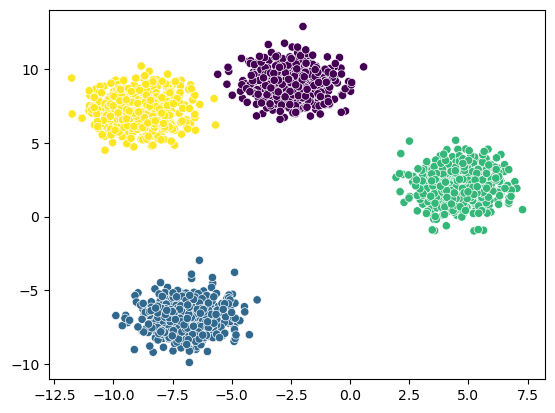

In [11]:
sns.scatterplot(
    x=X[:,0],
    y = X[:,1],
    c=labels
)

# Choosing the value of K

In [12]:
wcss = []
for k in range(1,21):
    model = KMeans(
        n_clusters=k,
        init = "k-means++",
        random_state=42
    )

    model.fit_predict(X)
    wcss.append(model.inertia_)

c:\Users\Asus\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=8.
  warnings.warn(
c:\Users\Asus\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=8.
  warnings.warn(
c:\Users\Asus\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=8.
  warnings.warn(
c:\Users\Asus\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows wi

<Axes: >

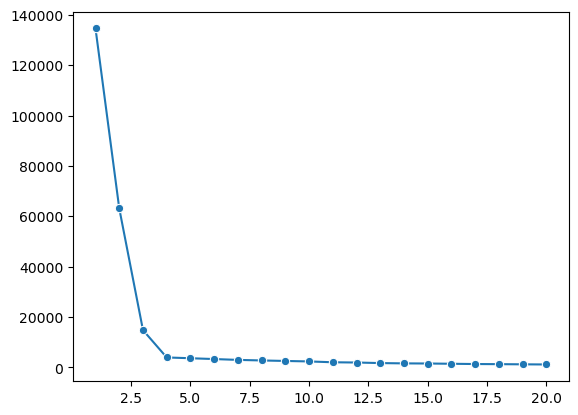

In [18]:
sns.lineplot(x = range(1,21),y=wcss,marker="o") # Elbow == 4

In [20]:
from kneed import KneeLocator

knee = KneeLocator(range(1,21),wcss,curve = "convex",direction = "decreasing")
print(knee.elbow)

4


# Silhouette Score

In [22]:
from sklearn.metrics import silhouette_score
ss = []
for k in range(2,21):
    model = KMeans(
        n_clusters=k,
        init = "k-means++",
        random_state=42
    )

    labels = model.fit_predict(X)
    
    ss.append(silhouette_score(X,labels=labels))


c:\Users\Asus\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=8.
  warnings.warn(
c:\Users\Asus\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=8.
  warnings.warn(
c:\Users\Asus\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=8.
  warnings.warn(
c:\Users\Asus\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows wi

<Axes: >

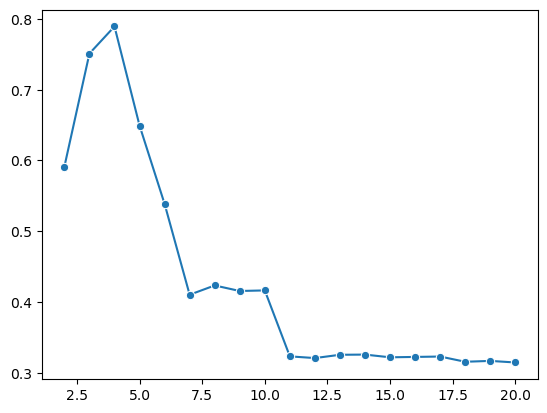

In [26]:
sns.lineplot(x = range(2,21),y = ss,marker='o') # K == 4